[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EnsaeStatApp/CorrelationEquityBond/blob/main/RegimeDetector/IOHMM_InSample_Regime_Analysis_EquityBond.ipynb)

# **Corrélation indices actions-obligations : Description des régimes de marchés entre le S&P et le T-Bond 10y de 70 à 2025 et du lien entre leurs changements et les variables macroéconomique**

Ce code est de la description pure (full in-sample). Il initialise un IOHMM et le fit sur les log returns du S&P et du T-Bond 10y de 1970 à 2025 et identifie 4 régimes de marchés distincts dont les transitions sont impactées par la macro. Pour comprendre ce que représente un régime, on utilise un objet de type RegimeStatisticalAnalyzer pour afficher les moyennes, volatilités et corrélations entre actifs conditionnellement à ce régime. Par ailleurs, des tests statistiques entre régimes sont appliqués (Levene pour les volatilités et Fisher-transfo pour les corrélations). Pour les paramètres de transitions, on obtient leur incertitude en approximant l'information de Fisher par la Hessienne numérique de la LL.


TO DO: rajouter le Box'M pour la matrice de cov complète


analyser précisément les standard errors calculées par l'info de fisher





# Connection au github

In [5]:
import os
import sys

# 1. Vérification de l'environnement
if 'google.colab' in str(get_ipython()):
    repo_url = 'https://github.com/EnsaeStatApp/CorrelationEquityBond.git'
    repo_name = 'CorrelationEquityBond'

    # 2. Clone du repo
    if not os.path.exists(repo_name):
        !git clone {repo_url}

    # 3. Déplacement dans le dossier du projet
    os.chdir(repo_name)

    # 4. Ajout du chemin au système pour l'import des modules .py
    sys.path.append(os.getcwd())

    print(f"Répertoire actuel : {os.getcwd()}")

Cloning into 'CorrelationEquityBond'...
remote: Enumerating objects: 600, done.
remote: Counting objects: 100% (204/204), done.
remote: Compressing objects: 100% (159/159), done.
remote: Total 600 (delta 141), reused 45 (delta 45), pack-reused 396 (from 3)
Receiving objects: 100% (600/600), 18.61 MiB | 31.34 MiB/s, done.
Resolving deltas: 100% (265/265), done.
Répertoire actuel : /content/CorrelationEquityBond/CorrelationEquityBond


# Installation de la librairie ssm via le repo git

In [6]:
!pip install git+https://github.com/lindermanlab/ssm.git

  Cloning https://github.com/lindermanlab/ssm.git to /tmp/pip-req-build-wl2ndhi7
  Running command git clone --filter=blob:none --quiet https://github.com/lindermanlab/ssm.git /tmp/pip-req-build-wl2ndhi7
  Resolved https://github.com/lindermanlab/ssm.git to commit eb6c8aa33e5311d3564075807dec340759dd8081
  Preparing metadata (setup.py) ... done


# Préparation des données

In [59]:
import pandas as pd
import numpy as np

df = pd.read_csv("monthly_data/dataset_stat_app_vf_with_gold.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date").sort_index()
df.drop(columns="Unnamed: 0", inplace=True)

In [60]:
from sklearn.preprocessing import StandardScaler


ASSET_VARS = ["Stock_Log_Return", "Bond_Log_Return"]
MACRO_VARS = ["inflation_yoy", "credit_spread_diff", "slope"]
asset_names = ["S&P", "T-bond 10y"]

# Feature Engineering Macro
df['inflation_yoy'] = df['CPI'].pct_change(12)
df['credit_spread'] = df['BAA'] - df['AAA']
df['credit_spread_diff'] = df['credit_spread'].diff()
df['slope'] = df['Rate GS10'] - df['TB3MS']

# Laggue 1
df[MACRO_VARS] = df[MACRO_VARS].shift(1)

cols_to_keep = ASSET_VARS + MACRO_VARS
df_model = df[cols_to_keep].dropna().copy()

# Masque temporel
dates = df_model.index
train_mask = (dates >= pd.Timestamp("1970-01-01")) & (dates <= pd.Timestamp("2025-01-01")) # full description à partir de 70

Y_train = df_model.loc[train_mask, ASSET_VARS].to_numpy(dtype=float)
X_train = df_model.loc[train_mask, MACRO_VARS].to_numpy(dtype=float)

#  Standardisation des covariables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

data_to_fit = [np.ascontiguousarray(Y_train * 100)]
input_to_fit = [np.ascontiguousarray(X_train_scaled)]

T, D = data_to_fit[0].shape
M = X_train_scaled.shape[1]


# Initialisation et fit du IOHMM descriptif

In [61]:
from RegimeDetector.HMMMarketWithMacroTransitionsRegimeDetector import HMMMarketWithMacroTransitionsRegimeDetector
from RegimeDetector.HMMCoherenceChecker import HMMCoherenceChecker

In [66]:
# Modèle IOHMM
detector_iohmm = HMMMarketWithMacroTransitionsRegimeDetector(
    n_regimes=4,
    n_dim=2,
    n_input=3,
    random_state=42, transition_kwargs={"alpha": 1, "kappa": 10, "l2_penalty": 1.5}
)

detector_iohmm.fit(observations=data_to_fit, inputs=input_to_fit, feature_names=MACRO_VARS, asset_names=asset_names)
states = detector_iohmm.viterbi_states

# Regarder la cohérence/stabilité du modèle
checker = HMMCoherenceChecker(
    detector=detector_iohmm,
    log_returns=data_to_fit[0],
    covariate_names=MACRO_VARS,
    asset_names=asset_names,
    min_duration=3.0,
    min_freq=0.05
)

checker.report_emission_stats() # paramètres d'émission
for ref_idx in range(4):
  checker.report_transition_stats(inputs=input_to_fit[0], ref_idx=ref_idx) # paramètres de transitioon

checker.final_verdict(inputs=input_to_fit[0]) # verdict final (automatisé)


Initialisation : Fit du HMM stationnaire...

AFFICHAGE DE L'INITIALISATION AVEC UN HMM STATIONNAIRE (EMISSION)
 Regime      Asset   N      Mean      Vol   Ann_Vol
      0        S&P  89 -2.157224 6.066754 21.015853
      0 T-bond 10y  89  1.024538 1.823782  6.317767
      1        S&P 360  1.443084 2.725281  9.440651
      1 T-bond 10y 360  0.648077 1.799775  6.234602
      2        S&P  61  0.230578 4.832204 16.739247
      2 T-bond 10y  61  0.178050 3.926812 13.602877
      3        S&P 151  1.514595 1.958588  6.784748
      3 T-bond 10y 151  0.072864 1.346776  4.665368

AFFICHAGE DE L'INITIALISATION AVEC UNE REGRESSION LOGISTIQUE (TRANSITION)

=== POIDS INITIAUX DE LA RÉGRESSION LOGISTIQUE (X_{t-1} -> Z_t) ===
                      Intercept  inflation_yoy  credit_spread_diff   slope
Probabilité Régime 0    -0.1403        -0.0031              0.3959 -0.1162
Probabilité Régime 1     1.3417         0.1485             -0.1970  0.0579
Probabilité Régime 2    -1.1330         1.2916      

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



DIAGNOSTIC COMPLET DES ÉMISSIONS (BOOTSTRAP & TESTS)

1. VOLATILITÉS ANNUELLES AVEC INTERVALLES DE CONFIANCE :


Value  Lower_Bound  Upper_Bound
Regime Label                                        
0      S&P         20.8106      16.7242      24.7236
       T-bond 10y   6.6441       5.5348       7.6469
1      S&P          9.3374       8.5567      10.1415
       T-bond 10y   5.9070       5.4512       6.3506
2      S&P         16.4134      13.3174      19.1075
       T-bond 10y  13.7578      10.9872      15.9754
3      S&P          7.7026       6.8657       8.4818
       T-bond 10y   5.1023       4.4814       5.6781


2. CORRÉLATIONS AVEC INTERVALLES DE CONFIANCE :


...

,Type,Transition,Variable,Coef,Std_Err,P_Value,Significatif
0,Intercept,R0 -> R0,Base_Prob,2.4079,0.7520,0.0014,True
1,Intercept,R0 -> R1,Base_Prob,-1.8311,1.7391,0.2924,False
2,Intercept,R0 -> R2,Base_Prob,-2.6787,3.1311,0.3923,False
3,Intercept,R1 -> R0,Base_Prob,-0.2333,1.3767,0.8655,False
4,Intercept,R1 -> R1,Base_Prob,4.8860,0.8786,0.0000,True
5,Intercept,R1 -> R2,Base_Prob,-0.4885,1.4666,0.7391,False
6,Intercept,R2 -> R0,Base_Prob,2.2006,6.2970,0.7267,False
7,Intercept,R2 -> R1,Base_Prob,3.8403,5.8514,0.5116,False
8,Intercept,R2 -> R2,Base_Prob,5.9657,5.6424,0.2904,False
9,Intercept,R3 -> R0,Base_Prob,-2.0623,0.5375,0.0001,True



2. DYNAMIQUE MOYENNE ET PERSISTANCE :


,Durée_Moyenne (mois),Prob_Stationnaire,Prob_Rester
0,7.1055,0.1884,0.8593
1,27.3708,0.5447,0.9635
2,6.0419,0.1099,0.8345
3,5.0466,0.1570,0.8018



RAPPORT DE COHÉRENCE HMM : 77.07%
1. SÉPARABILITÉ : 61.1% (Seuil: 50%) -> OK
2. STABILITÉ    : VALIDE
3. PERSISTANCE  : 5.0 mois (min 3.0) -> OK
4. CONFIANCE    : 80.2% (Entropie) -> SOLIDE
--------------------------------------------------
DYNAMIQUE DES RÉGIMES :
    Durée   Fréq
0   7.105  0.188
1  27.371  0.545
2   6.042  0.110
3   5.047  0.157

VERDICT : MODÈLE VALIDÉ (Robuste)


np.float64(0.7706604913831471)

On obtient donc des résultats proches de ceux du HMM Market, ce qui confirme une certaine stabilité. Par ailleurs, le modèle arrive à établir des liens cohérents et significatifs entre les variables macroéconomiques et les changements de régime de marché (ex : rôle de l'inflation significatif vers le régime 3 Stress inflationniste ou credit-spread significatif vers le régime 1 FTQ)

On semble donc identifier 4 régimes de marchés disincts

1.   Flight-to-quality (correl négative, haute vol, typique de 2008 ou 2020)
2.   Normal (correl positive, vol basse)
3.   Stress inflationniste (correl positive, haute vol, typique des années 70 ou de 2022)
4.   Diversification idéale (correl négative, vol basse vol, pré-2010)



Concernant les tests statistiques, les résultats de Levene et Fisher-Transfo sont convaincaints (au moins un des 2 est significatif pour chaque pair). Sur les paramètres de transition, pour tous les indices de références, les intercepts des transitions d'un régime vers lui-même sont significatifs. On peut surtout noter l'absence de valeurs propres négatives de l'info de Fisher et une entropie confirmée.

# Visualisation graphique

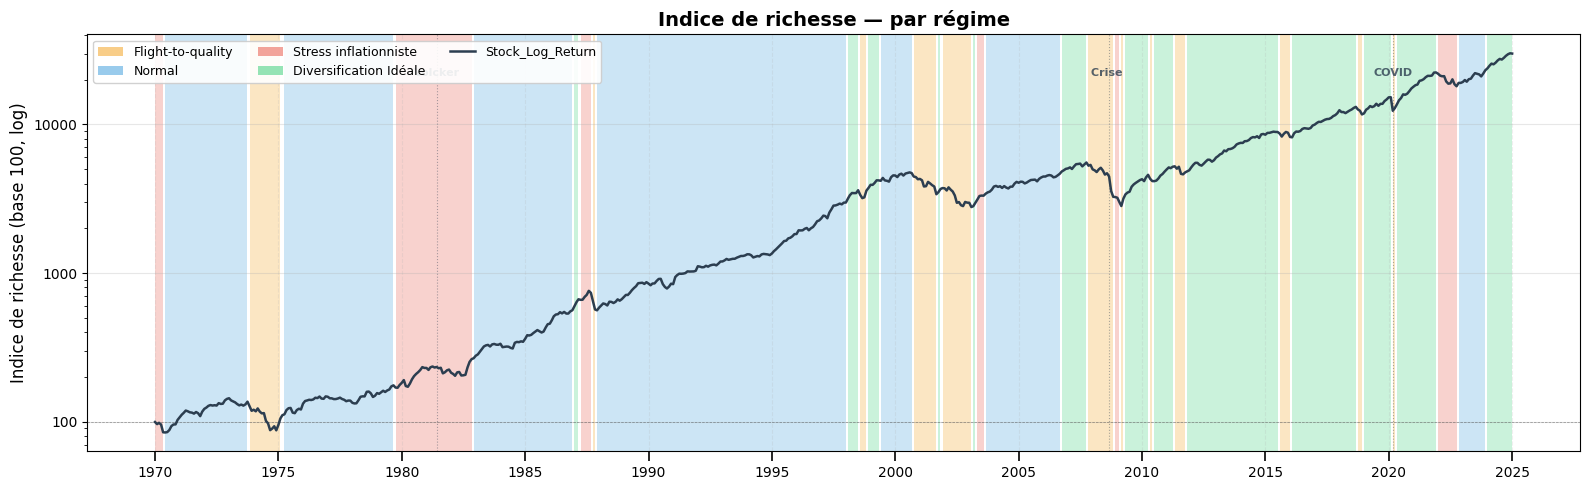

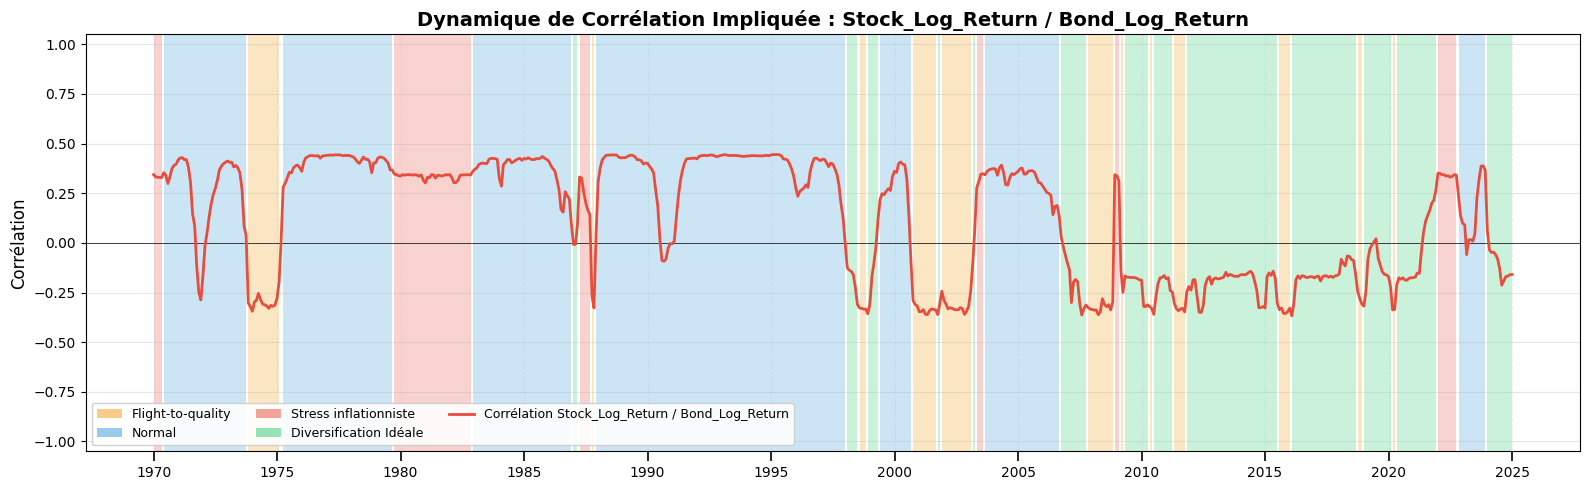

In [37]:
from RegimeDetector.RegimeReporter import RegimeReporter

mes_labels = {0: "Flight-to-quality", 1: "Normal", 2: "Stress inflationniste", 3: "Diversification Idéale"} # les 4 régimes identifiés
mes_couleurs = {0:"#f39c12", 1: "#3498db", 2: "#e74c3c", 3: "#2ecc71"} # choix des couleurs
mes_crises = {"Volcker": "1981-06-01", "Crise ": "2008-09-01","COVID": "2020-03-01",} # quelques dates pour les identifier + facilement

# Instanciation générique
visualizer = RegimeReporter(
    detector=detector_iohmm,
    log_returns=data_to_fit[0],
    dates=dates_train,
    states=states,
    asset_names=["Stock_Log_Return", "Bond_Log_Return"],
    regime_labels=mes_labels,
    regime_colors=mes_couleurs,
    events_dict=mes_crises
)

fig1 = visualizer.plot_wealth_index()
fig2 = visualizer.plot_implied_correlation()